In [1]:
# Install requirements if running in Colab
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install scikit-learn tqdm

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu117.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 51.5 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:0000:0100:01


[DEBUG] Loaded class type: disease with 4 classes: {'curl': 0, 'healthy': 1, 'leaf_spot': 2, 'pear_slug': 3}


/usr/local/lib/python3.11/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing
/usr/local/lib/python3.11/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


[DEBUG] __main__ started: initializing model and loaders...


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


[DEBUG] Model initialized. Starting training...
[DEBUG] Starting training loop...

[DEBUG] Epoch 1/20 ----------------------------
[DEBUG] Train Accuracy: 0.4564 | Loss: 1.2987
[DEBUG] Val   Accuracy: 0.7094 | Loss: 0.8721

[DEBUG] Epoch 2/20 ----------------------------
[DEBUG] Train Accuracy: 0.7599 | Loss: 0.8164
[DEBUG] Val   Accuracy: 0.8925 | Loss: 0.6044

[DEBUG] Epoch 3/20 ----------------------------
[DEBUG] Train Accuracy: 0.8736 | Loss: 0.6398
[DEBUG] Val   Accuracy: 0.9349 | Loss: 0.5218

[DEBUG] Epoch 4/20 ----------------------------
[DEBUG] Train Accuracy: 0.9058 | Loss: 0.5740
[DEBUG] Val   Accuracy: 0.9491 | Loss: 0.4876

[DEBUG] Epoch 5/20 ----------------------------
[DEBUG] Train Accuracy: 0.9335 | Loss: 0.5336
[DEBUG] Val   Accuracy: 0.9623 | Loss: 0.4588

[DEBUG] Epoch 6/20 ----------------------------


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[DEBUG] Train Accuracy: 0.9472 | Loss: 0.5005
[DEBUG] Val   Accuracy: 0.9679 | Loss: 0.4394

[DEBUG] Epoch 7/20 ----------------------------
[DEBUG] Train Accuracy: 0.9583 | Loss: 0.4815
[DEBUG] Val   Accuracy: 0.9755 | Loss: 0.4253

[DEBUG] Epoch 8/20 ----------------------------
[DEBUG] Train Accuracy: 0.9712 | Loss: 0.4553
[DEBUG] Val   Accuracy: 0.9764 | Loss: 0.4209

[DEBUG] Epoch 9/20 ----------------------------
[DEBUG] Train Accuracy: 0.9774 | Loss: 0.4418
[DEBUG] Val   Accuracy: 0.9792 | Loss: 0.4123

[DEBUG] Epoch 10/20 ----------------------------
[DEBUG] Train Accuracy: 0.9812 | Loss: 0.4313
[DEBUG] Val   Accuracy: 0.9811 | Loss: 0.4074

[DEBUG] Epoch 11/20 ----------------------------
[DEBUG] Train Accuracy: 0.9848 | Loss: 0.4222
[DEBUG] Val   Accuracy: 0.9792 | Loss: 0.4070

[DEBUG] Epoch 12/20 ----------------------------
[DEBUG] Train Accuracy: 0.9881 | Loss: 0.4168
[DEBUG] Val   Accuracy: 0.9821 | Loss: 0.4090

[DEBUG] Epoch 13/20 ----------------------------
[DEBUG] T

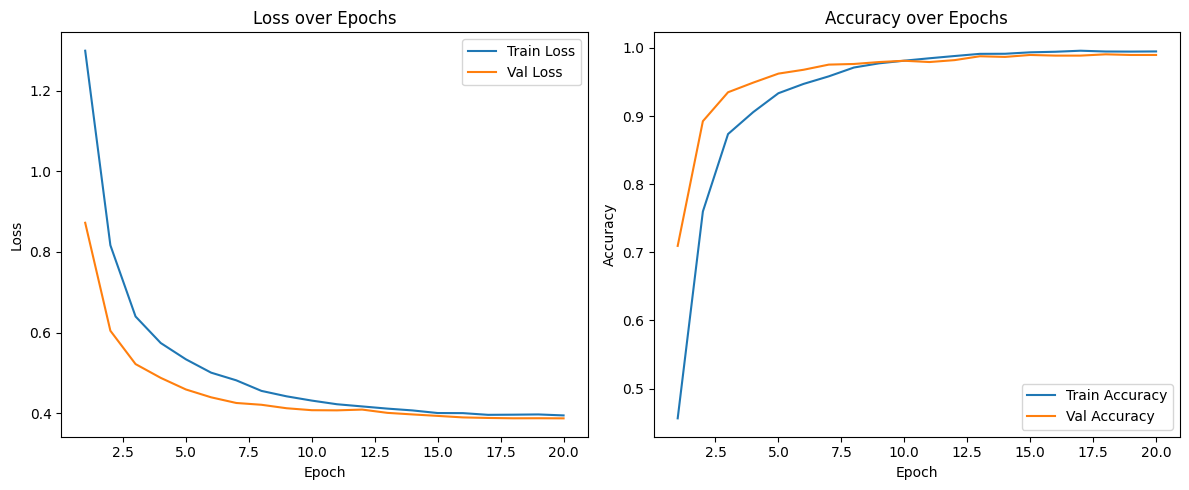

[DEBUG] Training complete. Starting testing phase...

[DEBUG] ----- Classification Metrics -----
Accuracy : 0.9887
Precision: 0.9891
Recall   : 0.9887
F1-score : 0.9887

[DEBUG] ----- Detailed Classification Report -----
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       221
           1     0.9959    1.0000    0.9979       240
           2     0.9646    1.0000    0.9820       300
           3     1.0000    0.9600    0.9796       300

    accuracy                         0.9887      1061
   macro avg     0.9901    0.9900    0.9899      1061
weighted avg     0.9891    0.9887    0.9887      1061

[DEBUG] Final Test Accuracy: 0.9887


In [2]:
# ------------------ Required Libraries ------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# ------------------ Device Configuration ------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

# ------------------ Config ------------------
BASE_DIR = "/kaggle/input/diamos-pear-leaves"
CLASS_TYPE = 'disease'
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

# ------------------ Data Augmentation ------------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ------------------ Dataset Loader ------------------
def load_dataset(split, class_type):
    image_paths, labels = [], []
    class_dir = os.path.join(BASE_DIR, split, class_type)
    class_names = sorted(os.listdir(class_dir))
    class_map = {name: idx for idx, name in enumerate(class_names)}
    for cname in class_names:
        cpath = os.path.join(class_dir, cname)
        for fname in os.listdir(cpath):
            image_paths.append(os.path.join(cpath, fname))
            labels.append(class_map[cname])
    return image_paths, labels, class_map

splits = ['train', 'val', 'test']
all_image_paths, all_labels = [], []
split_indices = {'train': [], 'val': [], 'test': []}
class_map = {}

for split in splits:
    paths, labels, current_class_map = load_dataset(split, CLASS_TYPE)
    if split == 'train':
        class_map = current_class_map
    start_idx = len(all_image_paths)
    end_idx = start_idx + len(paths)
    all_image_paths.extend(paths)
    all_labels.extend(labels)
    split_indices[split].extend(range(start_idx, end_idx))

print(f"[DEBUG] Loaded class type: {CLASS_TYPE} with {len(class_map)} classes: {class_map}")

class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ------------------ DataLoaders ------------------
train_loader = DataLoader(
    Subset(CustomImageDataset(all_image_paths, all_labels, train_transform), split_indices['train']),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

val_loader = DataLoader(
    Subset(CustomImageDataset(all_image_paths, all_labels, val_test_transform), split_indices['val']),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

test_loader = DataLoader(
    Subset(CustomImageDataset(all_image_paths, all_labels, val_test_transform), split_indices['test']),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

# ------------------ Channel Shuffle Utility ------------------
def channel_shuffle(x, groups):
    batchsize, num_channels, height, width = x.data.size()
    channels_per_group = num_channels // groups
    x = x.view(batchsize, groups, channels_per_group, height, width)
    x = torch.transpose(x, 1, 2).contiguous()
    x = x.view(batchsize, -1, height, width)
    return x

# ------------------ Depthwise Separable Conv ------------------
class depthwise_separable_conv(nn.Module):
    def __init__(self, nin, nout):
        super().__init__()
        self.depthwise = nn.Conv2d(nin, nin, kernel_size=3, stride=1, padding=1, groups=nin)
        self.pointwise = nn.Conv2d(nin, nout, kernel_size=1)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))
class GDSW(nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        groups = 32  # 1280 from EfficientNet is divisible by 32
        self.gc1 = nn.Conv2d(dim_in, 96, kernel_size=3, padding=1, groups=groups)
        self.cs = lambda x: channel_shuffle(x, groups=groups)
        self.DSWC = depthwise_separable_conv(96, 120)
        self.gc2 = nn.Conv2d(120, dim_out, kernel_size=3, stride=2, padding=1, groups=1)  # Fixed

    def forward(self, x):
        return self.gc2(self.DSWC(self.cs(self.gc1(x))))

class GDSW2(nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        groups = 3
        self.gc1 = nn.Conv2d(dim_in, 120, kernel_size=3, padding=1, groups=groups)
        self.cs = lambda x: channel_shuffle(x, groups=groups)
        self.DSWC = depthwise_separable_conv(120, 240)
        self.gc2 = nn.Conv2d(240, dim_out, kernel_size=3, stride=2, padding=1, groups=1)  # Fixed

    def forward(self, x):
        return self.gc2(self.DSWC(self.cs(self.gc1(x))))

class GDSW3(nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        groups = 3
        self.gc1 = nn.Conv2d(dim_in, 300, kernel_size=3, padding=1, groups=groups)
        self.cs = lambda x: channel_shuffle(x, groups=groups)
        self.DSWC = depthwise_separable_conv(300, 480)
        self.gc2 = nn.Conv2d(480, dim_out, kernel_size=3, stride=2, padding=1, groups=1)  # Fixed

    def forward(self, x):
        return self.gc2(self.DSWC(self.cs(self.gc1(x))))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class CoordAtt(nn.Module):
    def __init__(self, inp, oup, reduction=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = max(8, inp // reduction)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = nn.ReLU()

        self.conv_h = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        identity = x
        n, c, h, w = x.size()

        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y)

        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        a_h = self.conv_h(x_h).sigmoid()
        a_w = self.conv_w(x_w).sigmoid()

        out = identity * a_w * a_h
        return out


class GCNWithCoordAttention(nn.Module):
    def __init__(self, node_features, hidden_dim, out_features, dropout=0.3):
        super(GCNWithCoordAttention, self).__init__()
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_features)
        self.dropout = dropout
        self.coord_att = CoordAtt(1, 1)  # CoordAtt expects 4D: (B, C, H, W), so we use dummy C=1 here

    def forward(self, x, adj):
        # x: (N, node_features)
        x = self.conv1(x, adj)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, adj)  # (N, out_features)

        # Apply Coord Attention
        N = x.shape[0]
        side = int(N ** 0.5)
        x = x.view(1, 1, side, side * x.shape[1])  # Reshape for CoordAtt (B, C, H, W)
        x = self.coord_att(x)
        x = x.view(side * side, -1)  # (N, out_features)

        return x

from torch_geometric.utils import dense_to_sparse

def build_grid_edge_index(h, w, device):
    """
    Returns edge_index for a 2D grid graph (h x w) as required by torch_geometric GCNConv.
    """
    N = h * w
    adj = torch.zeros((N, N), device=device)

    for y in range(h):
        for x in range(w):
            idx = y * w + x
            neighbors = [
                (y-1, x-1), (y-1, x), (y-1, x+1),
                (y,   x-1),           (y,   x+1),
                (y+1, x-1), (y+1, x), (y+1, x+1)
            ]
            for ny, nx in neighbors:
                if 0 <= ny < h and 0 <= nx < w:
                    n_idx = ny * w + nx
                    adj[idx, n_idx] = 1.0

    edge_index, _ = dense_to_sparse(adj)
    return edge_index

# ------------------ Global Context Block ------------------
class ContextBlock(nn.Module):
    def __init__(self, inplanes, ratio):
        super().__init__()
        self.conv_mask = nn.Conv2d(inplanes, 1, kernel_size=1)
        self.softmax = nn.Softmax(dim=2)
        self.channel_add_conv = nn.Sequential(
            nn.Conv2d(inplanes, inplanes // ratio, kernel_size=1),
            nn.LayerNorm([inplanes // ratio, 1, 1]),
            nn.ReLU(inplace=True),
            nn.Conv2d(inplanes // ratio, inplanes, kernel_size=1)
        )

    def forward(self, x):
        batch, channel, height, width = x.size()
        context_mask = self.conv_mask(x).view(batch, 1, -1)
        context_mask = self.softmax(context_mask).view(batch, 1, height, width)
        context = torch.sum(x * context_mask, dim=(2, 3), keepdim=True)
        out = self.channel_add_conv(context)
        return x + out

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# ------------------ EfficientNetB0 ------------------
class EfficientNetB0(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.features = base_model.features

    def forward(self, x):
        return self.features(x)

# ------- Final Model Definition --------
class FinalModel(nn.Module):
    def __init__(self, num_classes=2):
        super(FinalModel, self).__init__()

        self.enla = EfficientNetB0()

        self.sh = GDSW(1280, 384)
        self.batchn = nn.BatchNorm2d(384)
        self.drop1 = nn.Dropout2d(p=0.3)

        self.sh2 = GDSW2(384, 192)
        self.batchn2 = nn.BatchNorm2d(192)
        self.drop2 = nn.Dropout2d(p=0.3)

        self.sh3 = GDSW3(192, 96)
        self.batchn3 = nn.BatchNorm2d(96)
        self.drop3 = nn.Dropout2d(p=0.3)

        self.gcn_layer = GCNWithCoordAttention(node_features=3, hidden_dim=64, out_features=96, dropout=0.3)
        self.gc_block = ContextBlock(96, 2)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(96, num_classes)
        )

    def forward(self, x):
        b, c, h_raw, w_raw = x.shape

        # -------- x1: EfficientNet + GDSW pipeline --------
        x1 = self.enla(x)           # (B, 1280, H/16, W/16)
        x1 = self.sh(x1)            # → (B, 384, H/16, W/16)
        x1 = self.batchn(x1)
        x1 = self.drop1(x1)

        x1 = self.sh2(x1)           # → (B, 192, H/16, W/16)
        x1 = self.batchn2(x1)
        x1 = self.drop2(x1)

        x1 = self.sh3(x1)           # → (B, 96, H/16, W/16)
        x1 = self.batchn3(x1)
        x1 = self.drop3(x1)

        # -------- x2: GCN path from resized raw image --------
        x_small = F.interpolate(x, size=(56, 56), mode='bilinear', align_corners=False)  # Resize raw input
        b, c, h, w = x_small.shape
        x_flat = x_small.view(b, 3, -1).permute(0, 2, 1)  # (B, N, 3)

        edge_index = build_grid_edge_index(h, w, device=x.device)

        gcn_out = []
        for i in range(b):
            gcn_features = self.gcn_layer(x_flat[i], edge_index)  # (N, 96)
            gcn_features = gcn_features.view(1, h, w, 96).permute(0, 3, 1, 2)  # (1, 96, H, W)
            gcn_out.append(gcn_features)

        x2 = torch.cat(gcn_out, dim=0)  # (B, 96, H, W)
        x2 = F.interpolate(x2, size=(x1.shape[2], x1.shape[3]), mode='bilinear', align_corners=False)

        x2 = self.gc_block(x2)

        # -------- Fusion + Classification --------
        y = x1 + x2
        return self.classifier(y)

# ------------------ Early Stopping ------------------
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


# ------------------ Training & Validation ------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0.0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == targets).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def validate_model(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == targets).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def test_model(model, loader, device):
    model.eval()
    correct, all_preds, all_targets = 0, [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())
            correct += (preds == targets).sum().item()

    # Compute metrics
    accuracy = correct / len(loader.dataset)
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

    print("\n[DEBUG] ----- Classification Metrics -----")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\n[DEBUG] ----- Detailed Classification Report -----")
    print(classification_report(all_targets, all_preds, digits=4))

    return accuracy, all_preds, all_targets


# ------------------ Plotting ------------------
def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------ Training Function ------------------
def train_model(model, train_loader, val_loader, device, epochs=EPOCHS):
    print("[DEBUG] Starting training loop...")
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = Adam(model.parameters(), lr=1e-4)

    warmup_epochs = 5
    warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=epochs - warmup_epochs)
    scheduler = SequentialLR(optimizer, [warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

    early_stopping = EarlyStopping(patience=5)
    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        print(f"\n[DEBUG] Epoch {epoch+1}/{epochs} ----------------------------")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_model(model, val_loader, criterion, device)

        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"[DEBUG] Train Accuracy: {train_acc:.4f} | Loss: {train_loss:.4f}")
        print(f"[DEBUG] Val   Accuracy: {val_acc:.4f} | Loss: {val_loss:.4f}")

        if early_stopping.step(val_loss):
            print(f"[DEBUG] Early stopping triggered at epoch {epoch+1}")
            break

    plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)



# ------------------ Main Execution ------------------
if __name__ == '__main__':
    print("[DEBUG] __main__ started: initializing model and loaders...")
    num_classes = len(class_map)
    model = FinalModel(num_classes=num_classes)  # Make sure Dropout is in FinalModel

    print("[DEBUG] Model initialized. Starting training...")
    train_model(model, train_loader, val_loader, device, epochs=EPOCHS)

    print("[DEBUG] Training complete. Starting testing phase...")
    test_acc, test_preds, test_labels = test_model(model, test_loader, device)
    print(f"[DEBUG] Final Test Accuracy: {test_acc:.4f}")


